**Mental Health in Tech Survey Analysis**

# Table of Contents
* [1. Project Setup](#chapter1)
* [2. Data Preparation](#chapter2)
* [3. Utility Functions](#chapter3)
* [4. Exploratory Data Analysis](#chapter4)
* [5. Statistical Analysis](#chapter5)
* [6. Segment Analysis](#chapter6)

## 1. Project Setup <a class="anchor" id="chapter1"></a>

In [1]:
# ============================================
# Import Libraries
# ============================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy.stats import chi2_contingency

In [2]:
# ============================================
# Global Configuration
# ============================================

# Seaborn Theme
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# Matplotlib Default Settings
plt.rcParams.update({

    # Figure
    "figure.figsize": (8, 5),
    "figure.dpi": 120,
    "savefig.dpi": 300,

    # Font
    "font.family": "DejaVu Sans",
    "font.size": 11,

    # Titles
    "axes.titlesize": 16,
    "axes.titleweight": "bold",

    # Axis Labels
    "axes.labelsize": 12,

    # Tick Labels
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # Legend
    "legend.fontsize": 10,

    # Grid
    "grid.color": "#ECECEC",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,

    # Axes
    "axes.edgecolor": "#D9D9D9"
})

In [3]:
# ============================================
# Project Constants
# ============================================

# Figure Sizes
FIG_SMALL = (8, 5)
FIG_MEDIUM = (10, 6)
FIG_WIDE = (12, 6)
FIG_LARGE = (16, 6)

ANNOTATION_SIZE = 10
TITLE_SIZE = 16
LABEL_SIZE = 12

In [4]:
# ============================================
# Project Color Palette
# ============================================

COLORS = {

    # Primary Blues
    "primary": "#2066A8",
    "secondary": "#8EC1DA",
    "light_blue": "#CDE1EC",

    # Neutral
    "neutral": "#EDEDED",
    "dark": "#2F3E46",
    "white": "#FFFFFF",

    # Accent Reds
    "light_red": "#F6D6C2",
    "red": "#D47264",
    "dark_red": "#AE282C",

    # Additional Accents
    "success": "#4F9D69",
    "warning": "#E5A63B"
}

In [5]:
# ============================================
# Color Collections
# ============================================

# Binary Variables
BINARY_COLORS = [
    COLORS["primary"],
    COLORS["red"]
]

# Ordered Categories
ORDERED_COLORS = [
    COLORS["primary"],
    COLORS["secondary"],
    COLORS["light_blue"],
    COLORS["light_red"],
    COLORS["dark_red"]
]

# Sequential Blue Palette
BLUE_PALETTE = [
    "#EAF4FB",
    "#CDE1EC",
    "#8EC1DA",
    "#2066A8"
]

# Sequential Red Palette
RED_PALETTE = [
    "#FCEDEA",
    "#F6D6C2",
    "#D47264",
    "#AE282C"
]

# Diverging Palette
DIVERGING_PALETTE = [
    "#2066A8",
    "#8EC1DA",
    "#CDE1EC",
    "#EDEDED",
    "#F6D6C2",
    "#D47264",
    "#AE282C"
]

In [6]:
# ============================================
# Load Dataset
# ============================================

DATA_PATH = "../data/survey.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 50)
print("Mental Health in Tech Survey Dataset")
print("=" * 50)
print(f"Dataset Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print()

display(df.head())

Mental Health in Tech Survey Dataset
Dataset Shape : 1,259 rows × 27 columns



,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


## 2. Data Preparation <a id="chapter2"></a>

In [7]:
# ============================================
# Check Column Names
# ============================================

df.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='str')

In [8]:
# ============================================
# Dataset Information
# ============================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

In [9]:
# ============================================
# Summary Statistics
# ============================================

df.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


In [10]:
# ============================================
# Age Outlier Detection
# ============================================

Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Age"] < lower_bound) |
    (df["Age"] > upper_bound)
]

print(f"Lower Bound : {lower_bound:.2f}")
print(f"Upper Bound : {upper_bound:.2f}")
print(f"Number of Outliers : {len(outliers)}")

display(outliers.head())

Lower Bound : 13.50
Upper Bound : 49.50
Number of Outliers : 40


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
38,2014-08-27 11:42:08,50,M,United States,IN,No,No,No,NaN,100-500,...,Don't know,No,No,Some of them,Yes,No,Maybe,Don't know,No,NaN
143,2014-08-27 12:39:14,-29,Male,United States,MN,No,No,No,NaN,More than 1000,...,Don't know,No,No,Some of them,Yes,No,No,Don't know,No,NaN
294,2014-08-27 14:15:57,56,Male,United States,NaN,No,No,Yes,Never,More than 1000,...,Don't know,No,Maybe,Yes,Some of them,No,Maybe,Don't know,No,NaN
297,2014-08-27 14:18:41,60,male,United States,CA,No,No,No,NaN,More than 1000,...,Don't know,No,No,Some of them,Yes,Maybe,Maybe,Yes,No,NaN
347,2014-08-27 14:45:45,54,M,United States,CA,No,Yes,Yes,Never,More than 1000,...,Don't know,No,No,No,Yes,No,No,Don't know,No,NaN


In [11]:
# ============================================
# Missing Values
# ============================================

df.isna().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

In [12]:
# ============================================
# Duplicate Records
# ============================================

df.duplicated().sum()

np.int64(0)

#### Data Cleaning

In [13]:
# ============================================
# Working Dataset
# ============================================

df_clean = df.copy()

In [14]:
# ============================================
# Drop the specified columns
# ============================================
columns_to_drop = [
    "comments",
    "state"
]

df_clean.drop(columns=columns_to_drop, inplace=True)

print(f"Updated dataset shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")

Updated dataset shape: 1,259 rows × 25 columns


In [15]:
# ============================================
# Fill missing values
# ============================================

# Fill missing values in 'self_employed' with the mode (most frequent value)
df_clean["self_employed"] = df_clean["self_employed"].fillna(
    df_clean["self_employed"].mode()[0]
)

print("=====Self Employed Value Counts:=====")
print(df_clean['self_employed'].value_counts())


# Fill missing values in 'work_interfere' with 'Unknown'
df_clean["work_interfere"] = df_clean["work_interfere"].fillna("Unknown")

print("=====Work Interfere Value Counts:=====")
print(df_clean['work_interfere'].value_counts())

=====Self Employed Value Counts:=====
self_employed
No     1113
Yes     146
Name: count, dtype: int64
=====Work Interfere Value Counts:=====
work_interfere
Sometimes    465
Unknown      264
Never        213
Rarely       173
Often        144
Name: count, dtype: int64


In [16]:
# ============================================
# Clean the 'Gender' Column
# ============================================

# Standardize the 'Gender' column by converting to lowercase and stripping whitespace
df_clean["Gender"] = df_clean["Gender"].str.lower().str.strip()

# Define lists of variations for Male and Female
male_variations = [
    "male","m","make","cis male","man","male-ish",
    "maile","something kinda male?","mal","male (cis)",
    "guy (-ish) ^_^","male leaning androgynous","msle",
    "mail","cis male","malr","cis man",
    "ostensibly male, unsure what that really means"
]

female_variations = [
    "female","f","woman","cis female",
    "female (cis)","femail","femake",
    "cis-female/femme"
]

# Create a new column 'Gender_Cleaned' to preserve the raw data for data auditing purposes
# df_clean.drop(columns=["comments"], inplace=True)

# 5. Map the variations using .isin() and .loc[]
df_clean.loc[df_clean["Gender"].isin(male_variations), "Gender"] = "Male"
df_clean.loc[df_clean["Gender"].isin(female_variations), "Gender"] = "Female"

# 6. Handle other gender expressions (Other) and Missing Values (Unknown)
# Create boolean masks for logical filtering
is_male_or_female = df_clean["Gender"].isin(["Male", "Female"])
is_missing_value = df_clean["Gender"].isin(["nan", "none", "unknown"]) | df_clean["Gender"].isnull()

# Group remaining non-binary/fluid valid text expressions into 'Other' (Ensure they are not null)
df_clean.loc[~is_male_or_female & ~is_missing_value, "Gender"] = "Other"

# Group original missing values or unidentifiable inputs into 'Unknown'
df_clean.loc[is_missing_value, "Gender"] = "Unknown"

# 7. Display final value counts to verify the cleaned data
print("=== Gender Column Distribution After Cleaning ===")
print(df_clean["Gender"].value_counts())

=== Gender Column Distribution After Cleaning ===
Gender
Male      995
Female    247
Other      17
Name: count, dtype: int64


In [17]:
df_clean.isna().sum()

Timestamp                    0
Age                          0
Gender                       0
Country                      0
self_employed                0
family_history               0
treatment                    0
work_interfere               0
no_employees                 0
remote_work                  0
tech_company                 0
benefits                     0
care_options                 0
wellness_program             0
seek_help                    0
anonymity                    0
leave                        0
mental_health_consequence    0
phys_health_consequence      0
coworkers                    0
supervisor                   0
mental_health_interview      0
phys_health_interview        0
mental_vs_physical           0
obs_consequence              0
dtype: int64

In [18]:
# ============================================
# Clean the 'Country' Column
# ============================================

# Clean the 'Country' column by stripping leading/trailing whitespace and removing common prefixes/suffixes
df_clean["Country"] = df_clean["Country"].str.strip(", The")

# To get the count of each unique value in the "Country" column, including NaN values
df_clean["Country"].value_counts(dropna=False)

Country
United States             751
United Kingdom            185
Canada                     72
Germany                    45
Netherlands                27
Ireland                    27
Australia                  21
Franc                      13
India                      10
New Zealand                 8
Switzerland                 7
Poland                      7
Italy                       7
Sweden                      7
Brazil                      6
South Africa                6
Belgium                     6
Israel                      5
Bulgaria                    4
Singapor                    4
Russia                      3
Mexico                      3
Austria                     3
Finland                     3
Portugal                    2
Colombia                    2
Croatia                     2
Denmark                     2
Greec                       2
Slovenia                    1
Costa Rica                  1
Latvia                      1
Romania                     1
Zi

In [19]:
# ============================================
# Clean the 'Age' Column
# ============================================

df_clean = df_clean[(df_clean["Age"] >= 18) & (df_clean["Age"] <= 70)]

In [20]:
# ============================================
# Create a new DataFrame containing only respondents from tech companies
# ============================================
df_tech = df_clean[df_clean["tech_company"] == "Yes"].copy()

df_tech.shape

(1025, 25)

In [21]:
# ============================================
# Clean the Column Names in df_tech
# ============================================

df_tech.columns = (
    df_tech.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [22]:
original = len(df)
after_age = len(df_clean)
after_tech = len(df_tech)

cleaning_summary = pd.DataFrame({
    "Step": [
        "Original Dataset",
        "After Removing Age Outliers",
        "Technology Companies Only"
    ],
    "Rows": [
        original,
        after_age,
        after_tech
    ],
    "Rows Removed": [
        0,
        original - after_age,
        after_age - after_tech
    ]
})

cleaning_summary

,Step,Rows,Rows Removed
0,Original Dataset,1259,0
1,After Removing Age Outliers,1250,9
2,Technology Companies Only,1025,225


## 3. Utility Functions <a class="anchor" id="chapter3"></a>

##### Visualization Functions

In [23]:
# ============================================
# Vertical Count Plot
# This function creates a vertical count plot with percentage labels for categorical variables.
# ============================================

def plot_count_vertical(data, column, title, order=None):

    if order is None:
        order = data[column].value_counts().index

    fig, ax = plt.subplots(figsize=FIG_SMALL)

    sns.countplot(
        data=data,
        x=column,
        order=order,
        color=COLORS["primary"],
        edgecolor="black",
        ax=ax
    )

    total = len(data)

    for patch in ax.patches:

        percentage = patch.get_height() / total * 100

        ax.annotate(
            f"{percentage:.1f}%",
            (
                patch.get_x() + patch.get_width() / 2,
                patch.get_height()
            ),
            ha="center",
            va="bottom"
        )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Number of Respondents")

    sns.despine()

    plt.tight_layout()
    plt.show()

In [24]:
# ============================================
# Horizontal Count Plot
# ============================================

def plot_count_horizontal(data, column, title, order=None):

    if order is None:
        order = data[column].value_counts().index

    fig, ax = plt.subplots(figsize=FIG_MEDIUM)

    sns.countplot(
        data=data,
        y=column,
        order=order,
        color=COLORS["primary"],
        edgecolor="black",
        ax=ax
    )

    total = len(data)

    for patch in ax.patches:

        percentage = patch.get_width() / total * 100

        ax.annotate(
            f"{percentage:.1f}%",
            (
                patch.get_width(),
                patch.get_y() + patch.get_height() / 2
            ),
            ha="left",
            va="center"
        )

    ax.set_title(title)
    ax.set_xlabel("Number of Respondents")
    ax.set_ylabel("")

    sns.despine()

    plt.tight_layout()
    plt.show()

In [25]:
# ============================================
# Summary Bar Plot
# ============================================

def plot_summary_bar(summary_data, title):

    summary_data = summary_data.sort_values(
        "Percentage",
        ascending=False
    )

    fig, ax = plt.subplots(figsize=FIG_MEDIUM)

    sns.barplot(
        data=summary_data,
        x="Percentage",
        y="Variable",
        color=COLORS["primary"],
        edgecolor="black",
        ax=ax
    )

    for patch in ax.patches:

        ax.annotate(
            f"{patch.get_width():.1f}%",
            (
                patch.get_width() + 1,
                patch.get_y() + patch.get_height() / 2
            ),
            va="center"
        )

    ax.set_xlim(0, 100)

    ax.set_title(title)
    ax.set_xlabel("Respondents (%)")
    ax.set_ylabel("")

    sns.despine()

    plt.tight_layout()
    plt.show()

##### Statistical Functions

In [26]:
# ============================================
# Cramer's V
# ============================================

def cramers_v(contingency_table):

    chi2 = chi2_contingency(contingency_table)[0]

    n = contingency_table.values.sum()

    rows, columns = contingency_table.shape

    return np.sqrt(
        chi2 / (n * (min(rows, columns) - 1))
    )


# ============================================
# Association Strength
# ============================================

def association_strength(cramers):

    if cramers < 0.10:
        return "Negligible"
    elif cramers < 0.30:
        return "Weak"
    elif cramers < 0.50:
        return "Moderate"
    else:
        return "Strong"


# ============================================
# Association Analysis
# ============================================

def association_analysis(data, predictors, target):

    summary = []

    for variable in predictors:

        if variable not in data.columns:
            print(f"'{variable}' was not found in the dataset.")
            continue

        contingency_table = pd.crosstab(
            data[variable],
            data[target]
        )

        chi2, p_value, _, _ = chi2_contingency(contingency_table)

        cramers = cramers_v(contingency_table)

        summary.append({

            "Variable": variable.replace("_", " ").title(),

            "Chi-Square": round(chi2, 2),

            "P-Value": round(p_value, 4),

            "Cramer's V": round(cramers, 3),

            "Strength": association_strength(cramers)

        })

    summary = (
        pd.DataFrame(summary)
        .sort_values(
            by=["Cramer's V", "P-Value"],
            ascending=[False, True]
        )
        .reset_index(drop=True)
    )

    summary.index += 1

    return summary

In [27]:
# ============================================
# Association Strength
# ============================================

def association_strength(cramers):

    if cramers < 0.10:
        return "Negligible"
    elif cramers < 0.30:
        return "Weak"
    elif cramers < 0.50:
        return "Moderate"
    else:
        return "Strong"

## 4. Exploratory Data Analysis <a class="anchor" id="chapter4"></a>

#### Demographic Analysis

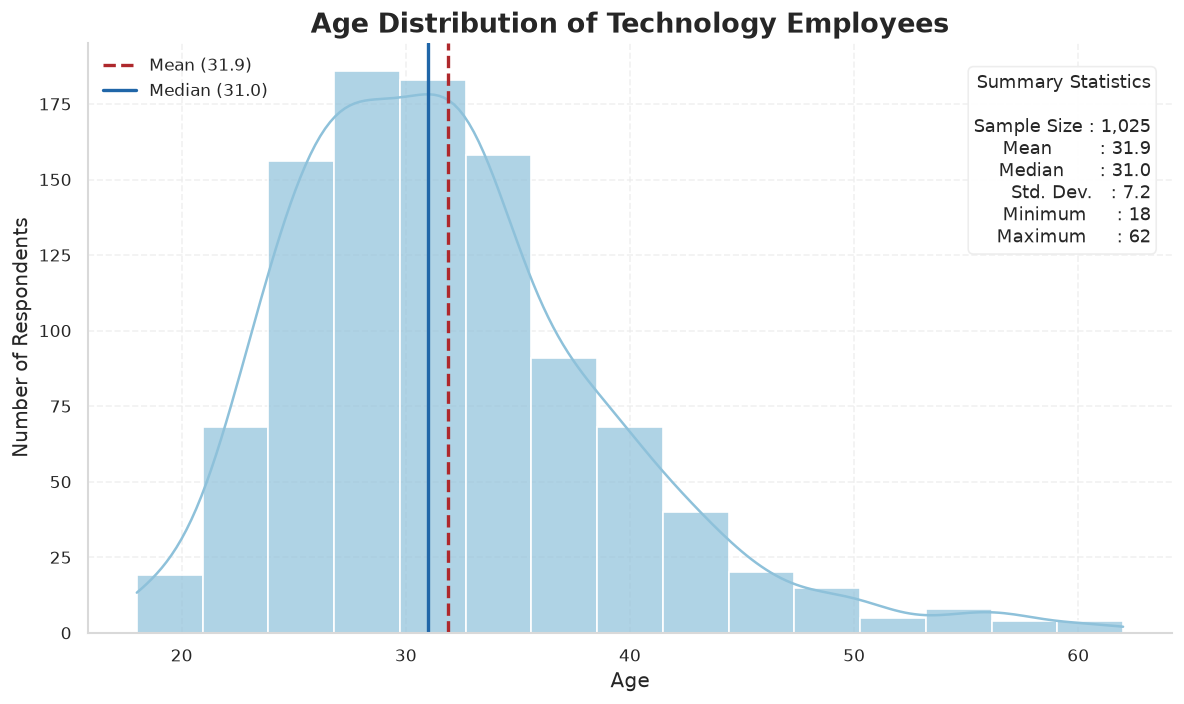

In [28]:
# ============================================
# Age Distribution of Technology Employees
# ============================================

# Summary Statistics
mean_age = df_tech["age"].mean()
median_age = df_tech["age"].median()
std_age = df_tech["age"].std()
min_age = df_tech["age"].min()
max_age = df_tech["age"].max()
n = len(df_tech)

# Create Figure
fig, ax = plt.subplots(figsize=FIG_MEDIUM)

sns.histplot(
    data=df_tech,
    x="age",
    bins=15,
    kde=True,
    color=COLORS["secondary"],
    alpha=0.7,
    edgecolor="white",
    ax=ax
)

# Mean Line
ax.axvline(
    mean_age,
    color=COLORS["dark_red"],
    linestyle="--",
    linewidth=2,
    label=f"Mean ({mean_age:.1f})"
)

# Median Line
ax.axvline(
    median_age,
    color=COLORS["primary"],
    linewidth=2,
    label=f"Median ({median_age:.1f})"
)

# Summary Statistics Box
summary_stats = (
    f"Summary Statistics\n\n"
    f"Sample Size : {n:,}\n"
    f"Mean        : {mean_age:.1f}\n"
    f"Median      : {median_age:.1f}\n"
    f"Std. Dev.   : {std_age:.1f}\n"
    f"Minimum     : {min_age}\n"
    f"Maximum     : {max_age}"
)

ax.text(
    0.98,
    0.95,
    summary_stats,
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor=COLORS["neutral"],
        alpha=0.95
    )
)

# Formatting
ax.set_title("Age Distribution of Technology Employees")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Respondents")

ax.legend(frameon=False)

sns.despine()

plt.tight_layout()
plt.show()

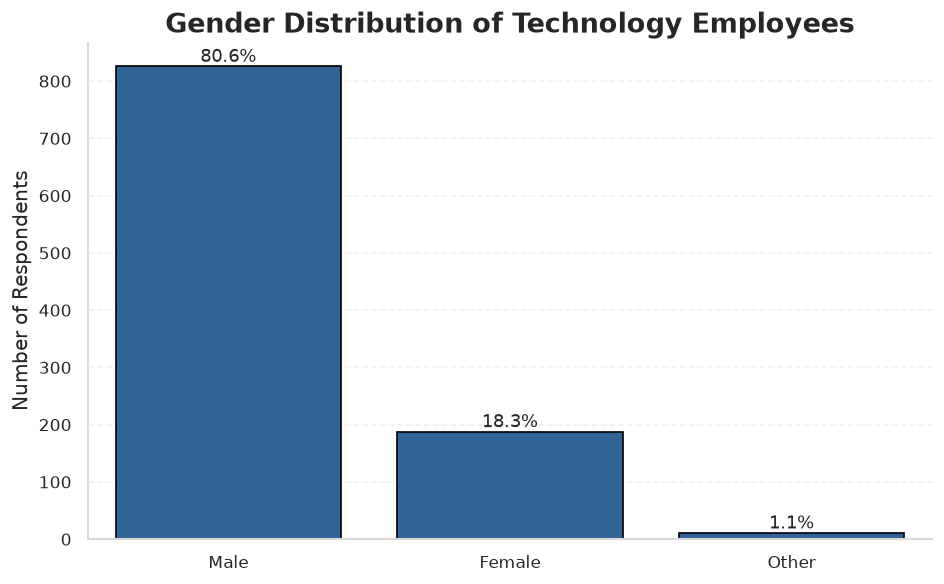

In [29]:
plot_count_vertical(
    df_tech,
    "gender",
    "Gender Distribution of Technology Employees"
)

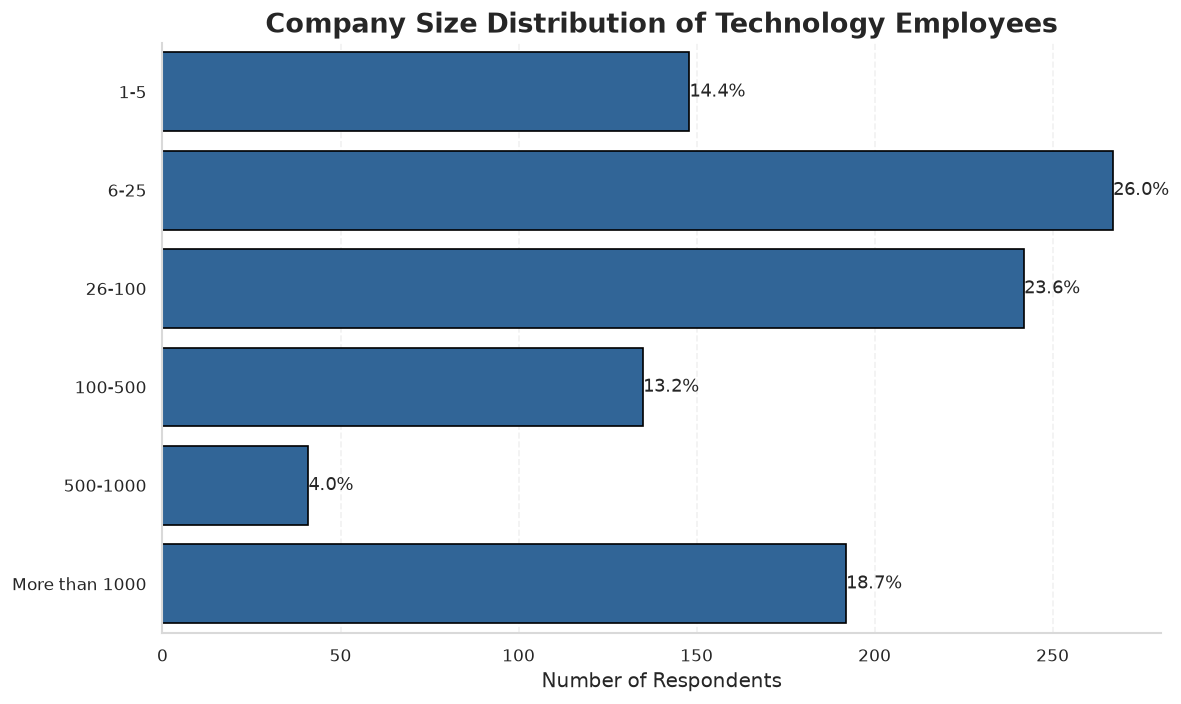

In [30]:
# Company Size Distribution of Technology Employees
plot_count_horizontal(
    df_tech,
    "no_employees",
    "Company Size Distribution of Technology Employees",
    order=[
        "1-5",
        "6-25",
        "26-100",
        "100-500",
        "500-1000",
        "More than 1000"
    ]
)

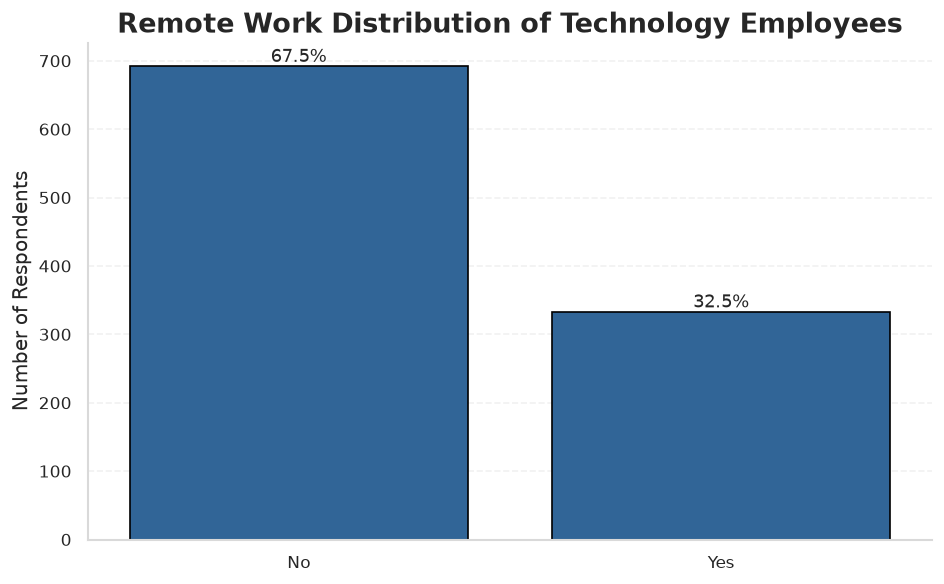

In [31]:
# Remote Work Distribution of Technology Employees
plot_count_vertical(
    df_tech,
    "remote_work",
    "Remote Work Distribution of Technology Employees",
)

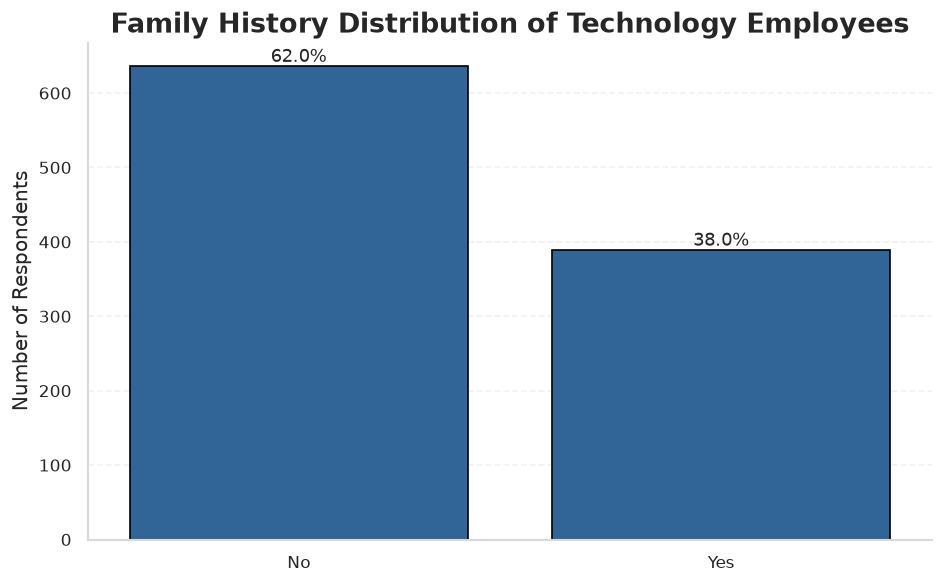

In [32]:
# Family History Distribution of Technology Employees
plot_count_vertical(
    df_tech,
    "family_history",
    "Family History Distribution of Technology Employees",
)

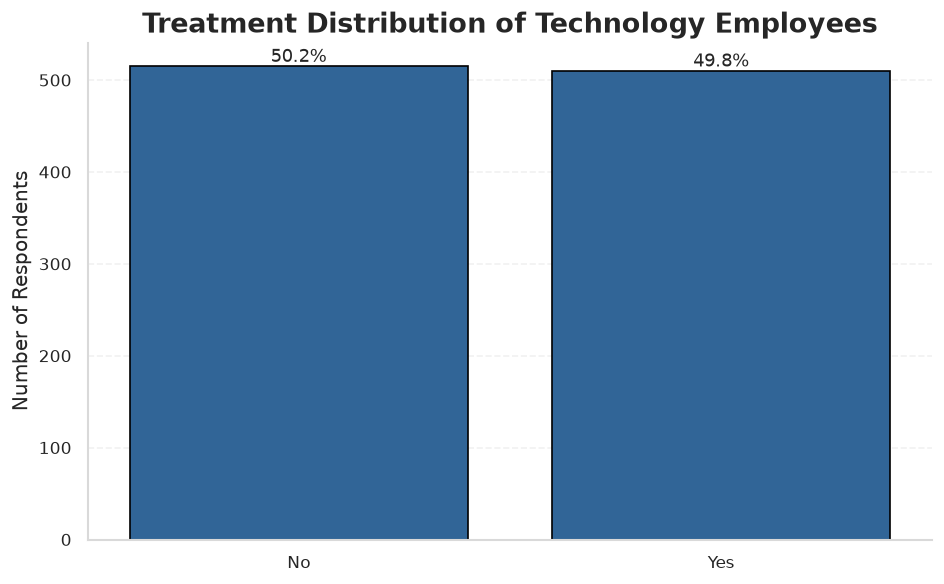

In [33]:
plot_count_vertical(
    df_tech,
    "treatment",
    "Treatment Distribution of Technology Employees",
)

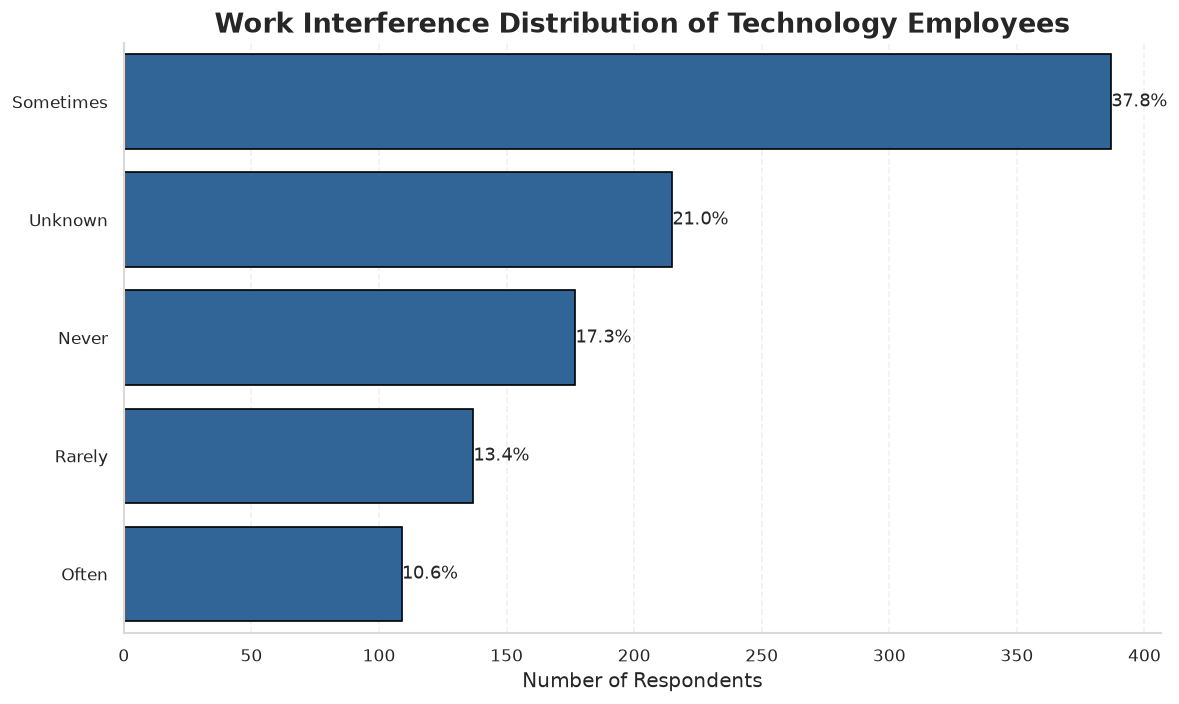

In [34]:
# Leave Distribution of Technology Employees
plot_count_horizontal(
    df_tech,
    "work_interfere",
    "Work Interference Distribution of Technology Employees",
)

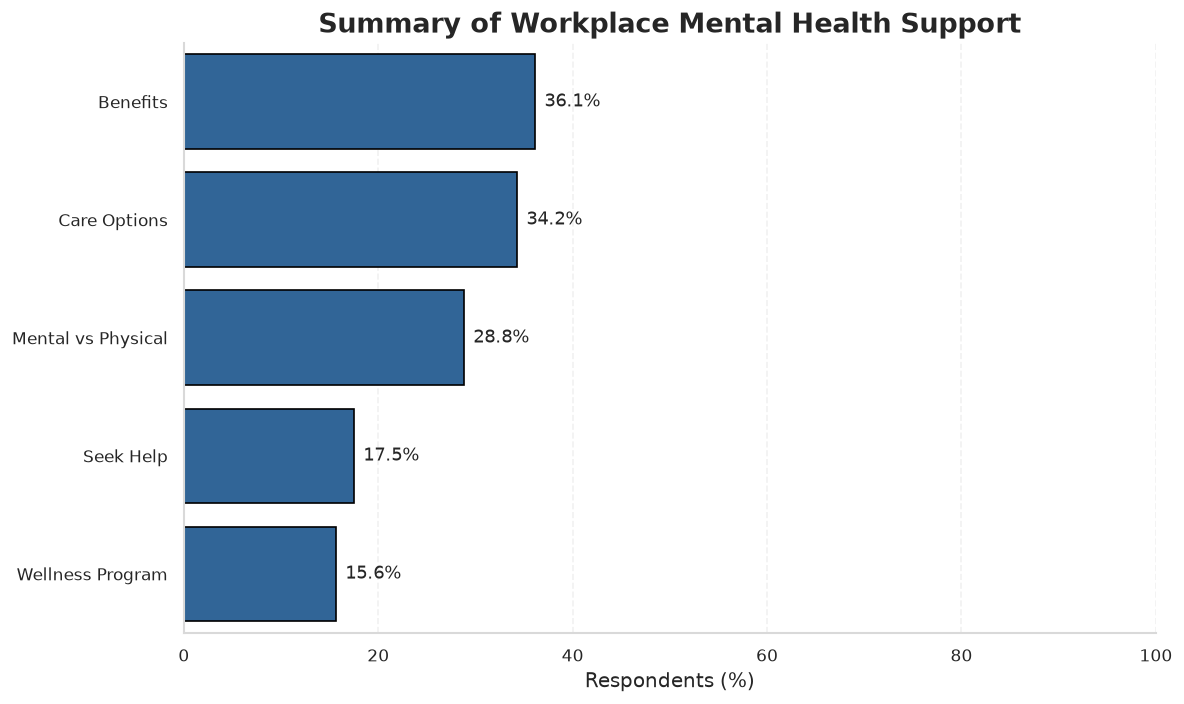

In [35]:
support_summary = pd.DataFrame({
    "Variable": [
        "Benefits",
        "Care Options",
        "Wellness Program",
        "Seek Help",
        "Mental vs Physical"
    ],
    "Percentage": [
        (df_tech["benefits"] == "Yes").mean() * 100,
        (df_tech["care_options"] == "Yes").mean() * 100,
        (df_tech["wellness_program"] == "Yes").mean() * 100,
        (df_tech["seek_help"] == "Yes").mean() * 100,
        (df_tech["mental_vs_physical"] == "Yes").mean() * 100
    ]
})

plot_summary_bar(
    support_summary,
    "Summary of Workplace Mental Health Support"
)

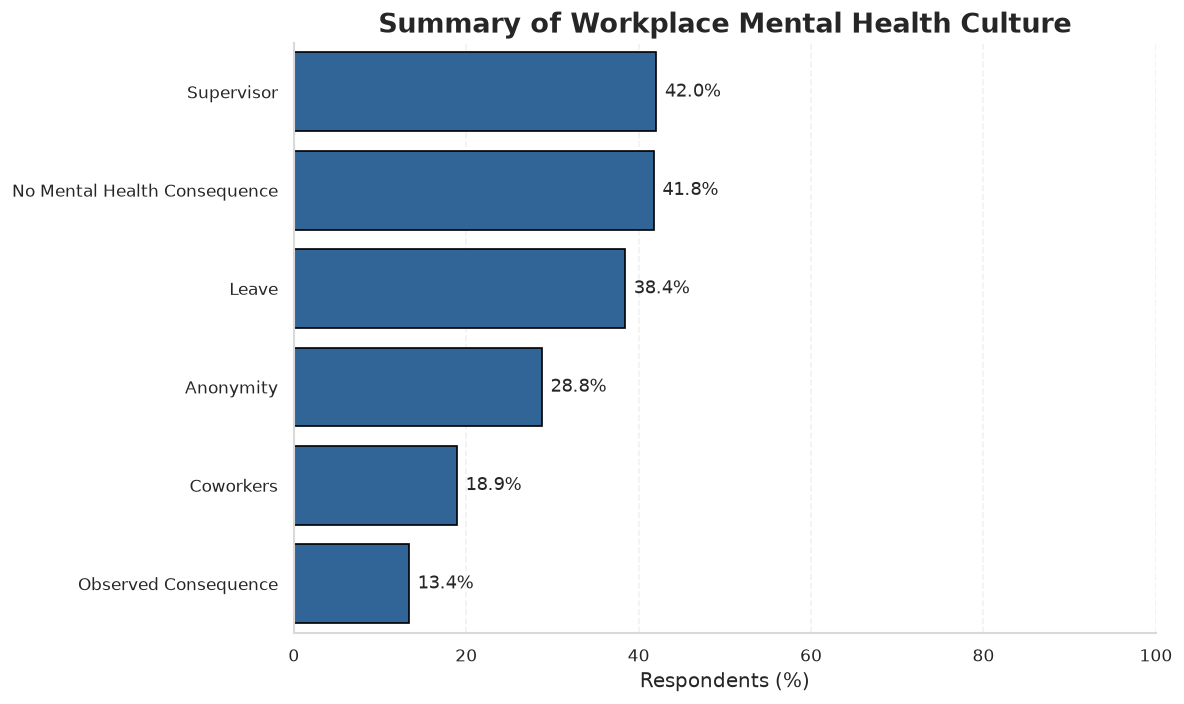

In [36]:
environment_summary = pd.DataFrame({
    "Variable": [
        "Leave",
        "Supervisor",
        "Coworkers",
        "Anonymity",
        "No Mental Health Consequence",
        "Observed Consequence"
    ],
    "Percentage": [
        (df_tech["leave"].isin(["Very easy", "Somewhat easy"]).mean() * 100),
        (df_tech["supervisor"] == "Yes").mean() * 100,
        (df_tech["coworkers"] == "Yes").mean() * 100,
        (df_tech["anonymity"] == "Yes").mean() * 100,
        (df_tech["mental_health_consequence"] == "No").mean() * 100,
        (df_tech["obs_consequence"] == "Yes").mean() * 100
    ]
})

plot_summary_bar(
    environment_summary,
    "Summary of Workplace Mental Health Culture"
)

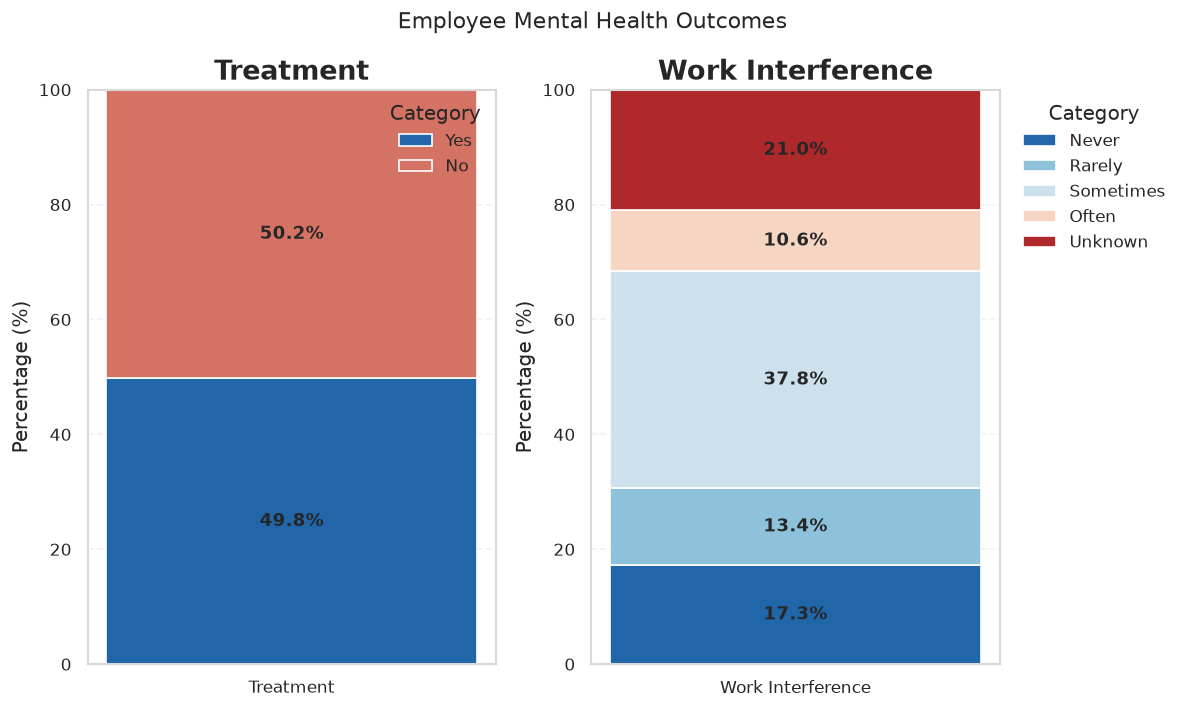

In [37]:
# ============================================
# Employee Mental Health Outcomes
# ============================================

# Treatment Distribution
treatment = (
    df_tech["treatment"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(["Yes", "No"])
)

# Work Interference Distribution
work = (
    df_tech["work_interfere"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex([
        "Never",
        "Rarely",
        "Sometimes",
        "Often",
        "Unknown"
    ])
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=FIG_MEDIUM
)

# ============================================
# Treatment
# ============================================

bottom = 0

for label, value, color in zip(
    treatment.index,
    treatment.values,
    BINARY_COLORS
):

    axes[0].bar(
        "Treatment",
        value,
        bottom=bottom,
        color=color,
        edgecolor="white",
        label=label
    )

    axes[0].text(
        0,
        bottom + value / 2,
        f"{value:.1f}%",
        ha="center",
        va="center",
        fontweight="bold"
    )

    bottom += value

axes[0].set_ylim(0, 100)
axes[0].set_ylabel("Percentage (%)")
axes[0].set_title("Treatment")
axes[0].legend(
    title="Category",
    frameon=False
)

# ============================================
# Work Interference
# ============================================

bottom = 0

for label, value, color in zip(
    work.index,
    work.values,
    ORDERED_COLORS
):

    axes[1].bar(
        "Work Interference",
        value,
        bottom=bottom,
        color=color,
        edgecolor="white",
        label=label
    )

    if value >= 4:

        axes[1].text(
            0,
            bottom + value / 2,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontweight="bold"
        )

    bottom += value

axes[1].set_ylim(0, 100)
axes[1].set_ylabel("Percentage (%)")
axes[1].set_title("Work Interference")
axes[1].legend(
    title="Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

fig.suptitle("Employee Mental Health Outcomes")

plt.tight_layout()
plt.show()

## 5. Statistical Analysis <a id="chapter5"></a>

In [38]:
NON_ACTIONABLE_FACTORS = [
    "age",
    "gender",
    "family_history"
]

ACTIONABLE_FACTORS = [
    "benefits",
    "care_options",
    "wellness_program",
    "seek_help",
    "anonymity",
    "leave",
    "coworkers",
    "supervisor",
    "mental_vs_physical",
    "mental_health_consequence",
    "obs_consequence",
    "no_employees",
    "remote_work"
]



In [39]:
treatment_non_actionable = association_analysis(
    data=df_tech,
    predictors=NON_ACTIONABLE_FACTORS,
    target="treatment"
)

treatment_actionable = association_analysis(
    data=df_tech,
    predictors=ACTIONABLE_FACTORS,
    target="treatment"
)

work_non_actionable = association_analysis(
    data=df_tech,
    predictors=NON_ACTIONABLE_FACTORS,
    target="work_interfere"
)

work_actionable = association_analysis(
    data=df_tech,
    predictors=ACTIONABLE_FACTORS,
    target="work_interfere"
)

print("=== Association with Treatment (Non-Actionable Factors) ===")
display(treatment_non_actionable)

print("=== Association with Treatment (Actionable Factors) ===")
display(treatment_actionable)   

print("=== Association with Work Interference (Non-Actionable Factors) ===")
display(work_non_actionable)

print("=== Association with Work Interference (Actionable Factors) ===")
display(work_actionable)

=== Association with Treatment (Non-Actionable Factors) ===


,Variable,Chi-Square,P-Value,Cramer's V,Strength
1,Family History,152.57,0.0000,0.386,Moderate
2,Gender,38.64,0.0000,0.194,Weak
3,Age,36.49,0.7111,0.189,Weak


=== Association with Treatment (Actionable Factors) ===


,Variable,Chi-Square,P-Value,Cramer's V,Strength
1,Care Options,71.83,0.0000,0.265,Weak
2,Benefits,49.51,0.0000,0.220,Weak
3,Leave,18.10,0.0012,0.133,Weak
4,Anonymity,16.63,0.0002,0.127,Weak
5,Mental Health Consequence,16.10,0.0003,0.125,Weak
6,Obs Consequence,12.60,0.0004,0.111,Weak
7,Mental Vs Physical,10.75,0.0046,0.102,Weak
8,Coworkers,9.55,0.0084,0.097,Negligible
9,No Employees,6.74,0.2406,0.081,Negligible
10,Seek Help,5.78,0.0556,0.075,Negligible


=== Association with Work Interference (Non-Actionable Factors) ===


,Variable,Chi-Square,P-Value,Cramer's V,Strength
1,Family History,134.89,0.0000,0.363,Moderate
2,Age,152.48,0.7988,0.193,Weak
3,Gender,29.78,0.0002,0.121,Weak


=== Association with Work Interference (Actionable Factors) ===


,Variable,Chi-Square,P-Value,Cramer's V,Strength
1,Obs Consequence,28.19,0.0000,0.166,Weak
2,Benefits,48.61,0.0000,0.154,Weak
3,Care Options,48.70,0.0000,0.154,Weak
4,Mental Health Consequence,46.21,0.0000,0.150,Weak
5,Leave,63.45,0.0000,0.124,Weak
6,Seek Help,27.26,0.0006,0.115,Weak
7,Mental Vs Physical,24.27,0.0021,0.109,Weak
8,Supervisor,23.72,0.0026,0.108,Weak
9,Wellness Program,16.06,0.0416,0.089,Negligible
10,No Employees,28.00,0.1094,0.083,Negligible


In [40]:
# ============================================
# Cramer's V Ranking Plot
# ============================================

def plot_cramers_v(ranking, title, top_n=10):

    ranking = (
        ranking
        .head(top_n)
        .sort_values(
            by="Cramer's V",
            ascending=False
        )
    )

    fig, ax = plt.subplots(figsize=FIG_MEDIUM)

    sns.barplot(
        data=ranking,
        x="Cramer's V",
        y="Variable",
        color=COLORS["primary"],
        edgecolor="black",
        ax=ax
    )

    for patch in ax.patches:

        ax.annotate(
            f"{patch.get_width():.3f}",
            (
                patch.get_width() + 0.005,
                patch.get_y() + patch.get_height()/2
            ),
            va="center"
        )

    ax.set_title(title)
    ax.set_xlabel("Cramer's V")
    ax.set_ylabel("")

    sns.despine()

    plt.tight_layout()
    plt.show()

In [41]:
ALL_FACTORS = (
    NON_ACTIONABLE_FACTORS +
    ACTIONABLE_FACTORS
)

In [42]:
treatment_ranking = association_analysis(
    data=df_tech,
    predictors=ALL_FACTORS,
    target="treatment"
)

work_ranking = association_analysis(
    data=df_tech,
    predictors=ALL_FACTORS,
    target="work_interfere"
)

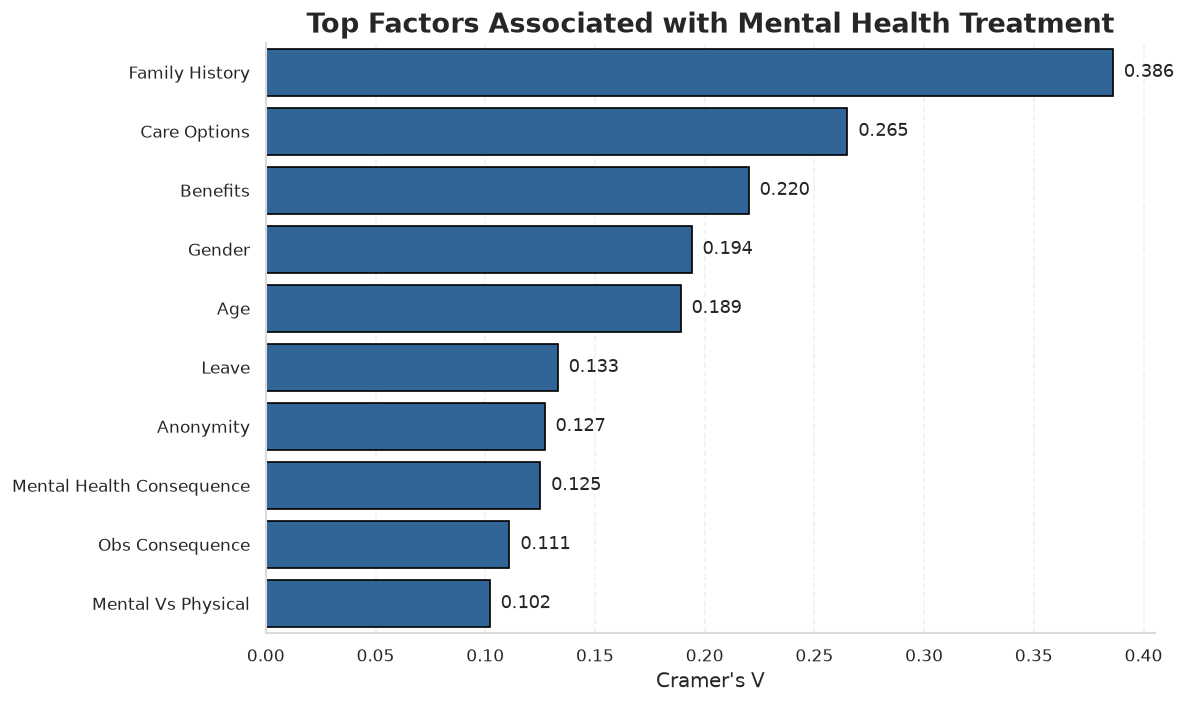

In [43]:
plot_cramers_v(
    treatment_ranking,
    "Top Factors Associated with Mental Health Treatment"
)

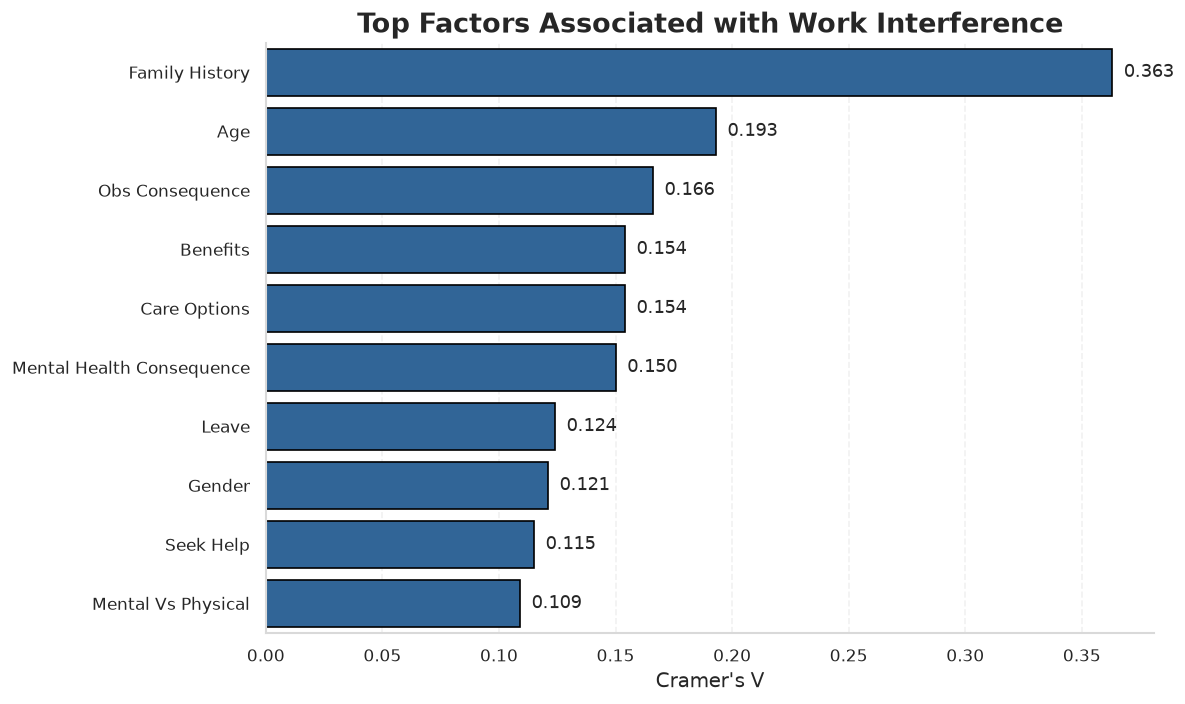

In [44]:
plot_cramers_v(
    work_ranking,
    "Top Factors Associated with Work Interference"
)

In [45]:
# ============================================
# Top Associated Factors
# ============================================

def plot_top_factors(data, target, ranking, top_n=3):

    variables = (
        ranking["Variable"]
        .head(top_n)
        .str.lower()
        .str.replace(" ", "_")
        .tolist()
    )

    if target == "treatment":

        colors = BINARY_COLORS

    else:

        colors = ORDERED_COLORS

    fig, axes = plt.subplots(
        1,
        top_n,
        figsize=FIG_LARGE
    )

    if top_n == 1:
        axes = [axes]

    for ax, variable in zip(axes, variables):

        # =====================================
        # Convert Age into Age Groups
        # =====================================

        if variable == "age":

            percentage = (
                pd.crosstab(
                    pd.cut(
                        data["age"],
                        bins=[18, 25, 35, 45, 55, 70],
                        labels=[
                            "18-25",
                            "26-35",
                            "36-45",
                            "46-55",
                            "56-70"
                        ],
                        include_lowest=True
                    ),
                    data[target],
                    normalize="index"
                )
                * 100
            )

        else:

            percentage = (
                pd.crosstab(
                    data[variable],
                    data[target],
                    normalize="index"
                )
                * 100
            )

        # Keep category order consistent
        if target == "work_interfere":

            percentage = percentage.reindex(
                columns=[
                    "Never",
                    "Rarely",
                    "Sometimes",
                    "Often",
                    "Unknown"
                ]
            )

        elif target == "treatment":

            percentage = percentage.reindex(
                columns=[
                    "Yes",
                    "No"
                ]
            )

        percentage.plot(
            kind="bar",
            stacked=True,
            color=colors[:len(percentage.columns)],
            edgecolor="black",
            ax=ax
        )

        ax.set_title(
            variable.replace("_", " ").title()
        )

        ax.set_xlabel("")
        ax.set_ylabel("Percentage (%)")

        ax.set_ylim(0, 100)

        ax.tick_params(
            axis="x",
            rotation=35
        )

        for container in ax.containers:

            labels = [
                f"{bar.get_height():.1f}%"
                if bar.get_height() >= 5
                else ""
                for bar in container
            ]

            ax.bar_label(
                container,
                labels=labels,
                label_type="center",
                color="white"
            )

        ax.legend_.remove()

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        title=target.replace("_", " ").title(),
        loc="upper center",
        bbox_to_anchor=(0.5, 0.98),
        ncol=len(labels),
        frameon=False
    )

    fig.suptitle(
        f"Top {top_n} Factors Associated with {target.replace('_', ' ').title()}",
        fontsize=18,
        fontweight="bold",
        y=1.04
    )

    plt.tight_layout(rect=[0, 0, 1, 0.90])

    plt.show()

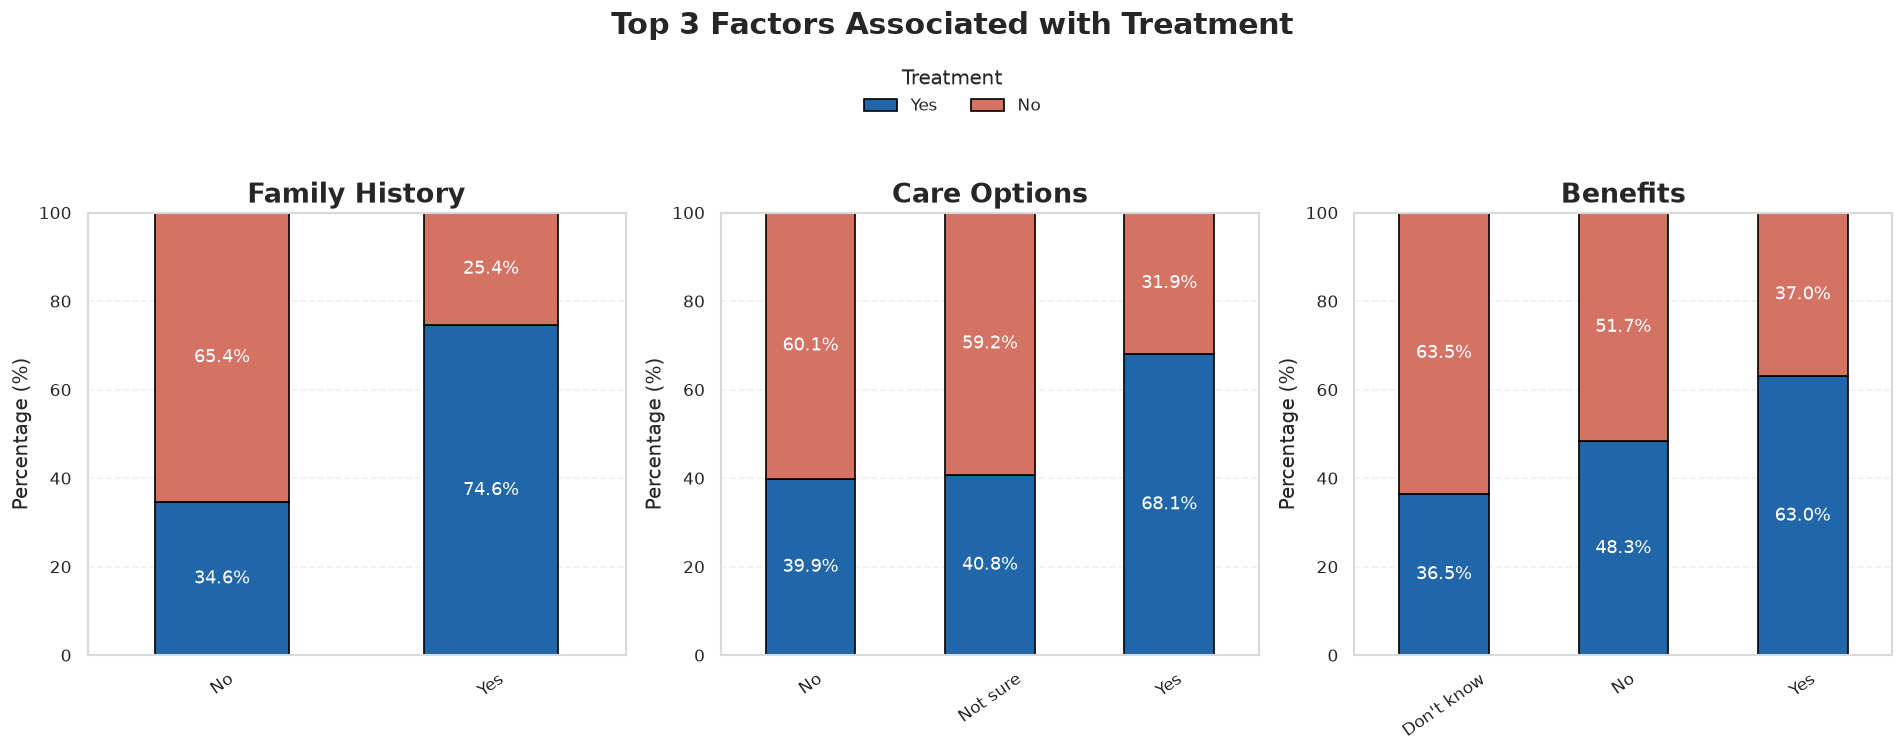

In [46]:
plot_top_factors(
    data=df_tech,
    target="treatment",
    ranking=treatment_ranking
)

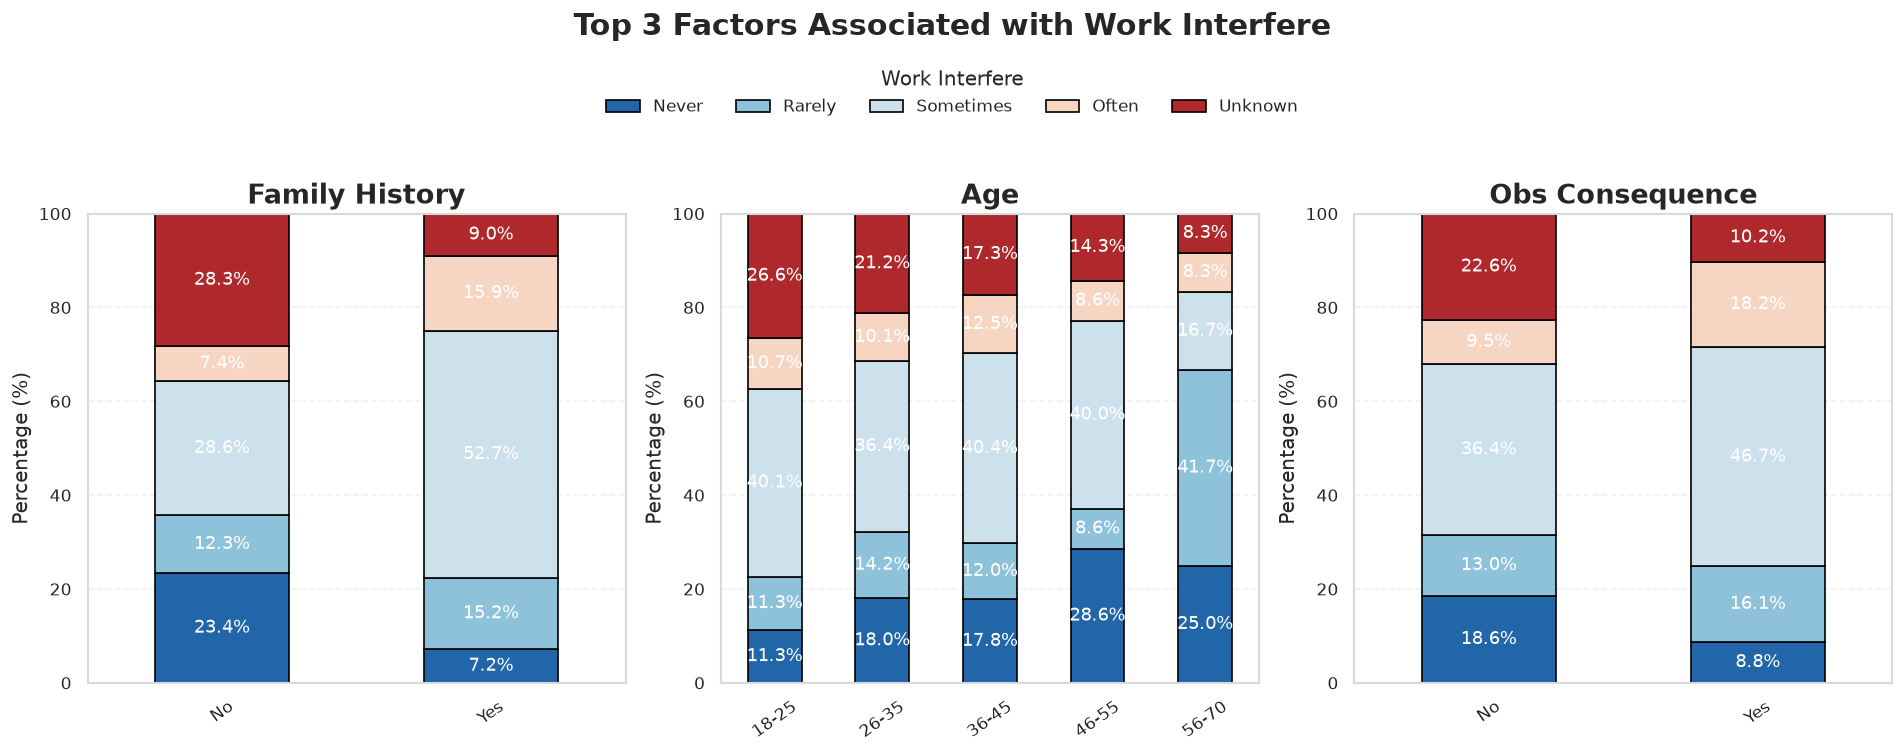

In [47]:
plot_top_factors(
    data=df_tech,
    target="work_interfere",
    ranking=work_ranking
)

## 6. Segment Analysis <a id="chapter6"></a>

In [48]:
bins = [18, 25, 35, 45, 55, 70]
labels = ["18-24", "25-34", "35-44", "45-54", "55-70"]

df_tech["age_group"] = pd.cut(
    df_tech["age"],
    bins=bins,
    labels=labels,
    right=False
)

In [49]:
# ============================================
# Employee Segment Analysis
# ============================================

def plot_segment_analysis(data, target, title):

    segments = [
        ("age_group", "Age Group"),
        ("no_employees", "Company Size"),
        ("remote_work", "Remote Work")
    ]

    if target == "treatment":

        colors = BINARY_COLORS
        category_order = ["Yes", "No"]

    else:

        colors = ORDERED_COLORS
        category_order = [
            "Never",
            "Rarely",
            "Sometimes",
            "Often",
            "Unknown"
        ]

    fig, axes = plt.subplots(
        1,
        len(segments),
        figsize=FIG_LARGE
    )

    for ax, (column, subtitle) in zip(axes, segments):

        percentage = (
            pd.crosstab(
                data[column],
                data[target],
                normalize="index"
            )
            .reindex(columns=category_order)
            * 100
        )

        percentage.plot(
            kind="bar",
            stacked=True,
            color=colors[:len(percentage.columns)],
            edgecolor="black",
            ax=ax
        )

        ax.set_title(subtitle)

        ax.set_xlabel("")
        ax.set_ylabel("Percentage (%)")

        ax.set_ylim(0, 100)

        ax.tick_params(
            axis="x",
            rotation=45
        )

        for container in ax.containers:

            labels = [

                f"{bar.get_height():.1f}%"

                if bar.get_height() >= 5

                else ""

                for bar in container

            ]

            ax.bar_label(
                container,
                labels=labels,
                label_type="center",
                color="white"
            )

        ax.legend_.remove()

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        title=target.replace("_", " ").title(),
        loc="upper center",
        bbox_to_anchor=(0.5, 0.98),
        ncol=len(labels),
        frameon=False
    )

    fig.suptitle(
        title,
        y=1.04
    )

    plt.tight_layout(rect=[0, 0, 1, 0.90])

    plt.show()

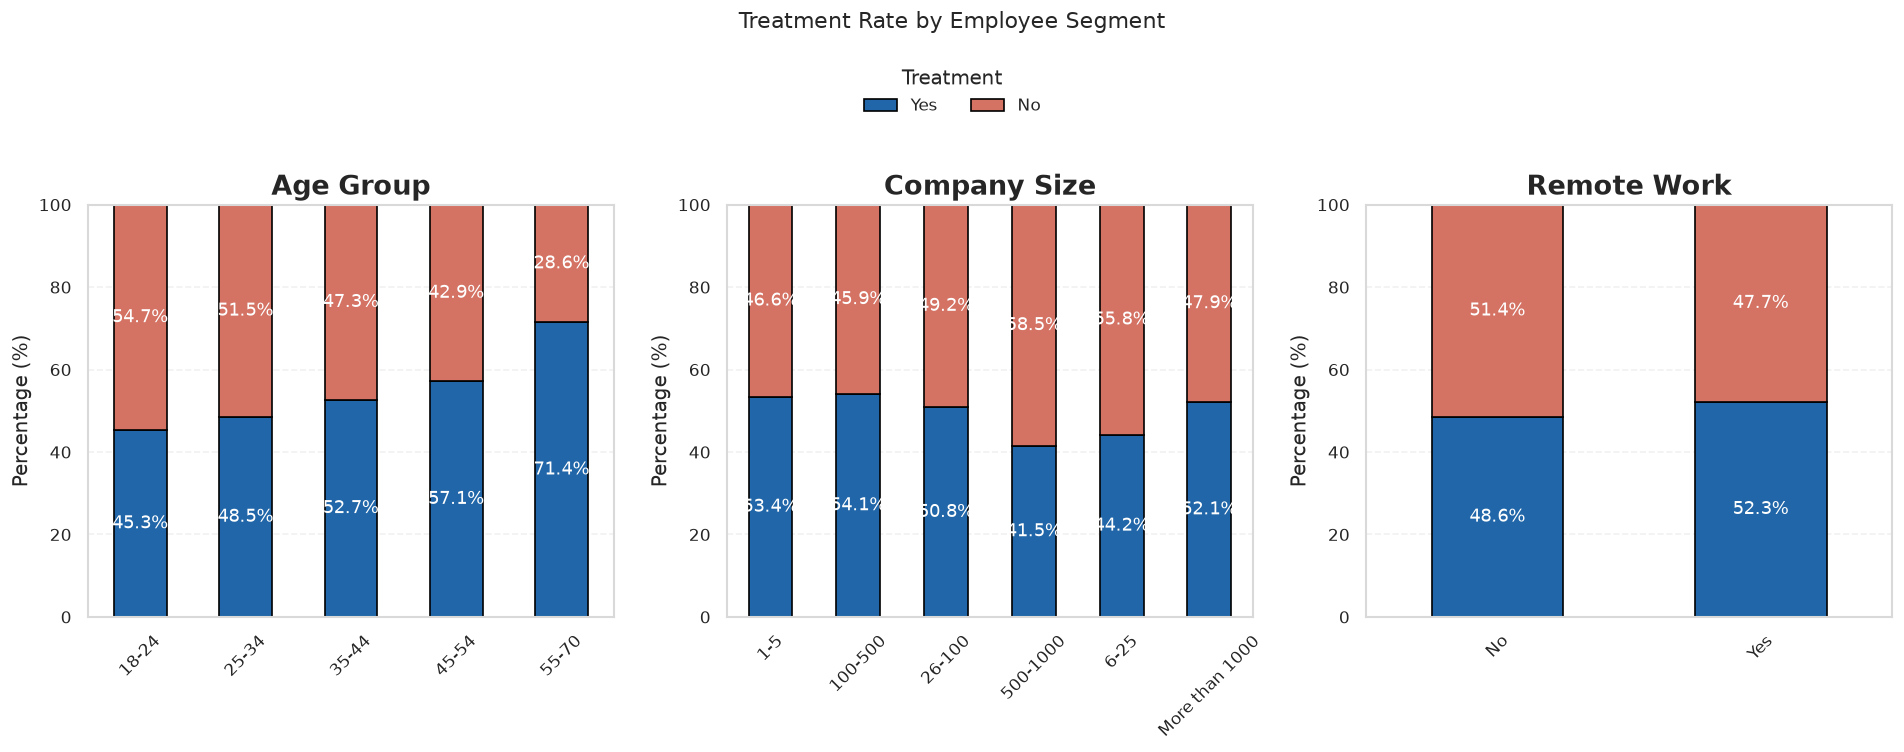

In [50]:
plot_segment_analysis(
    df_tech,
    target="treatment",
    title="Treatment Rate by Employee Segment"
)

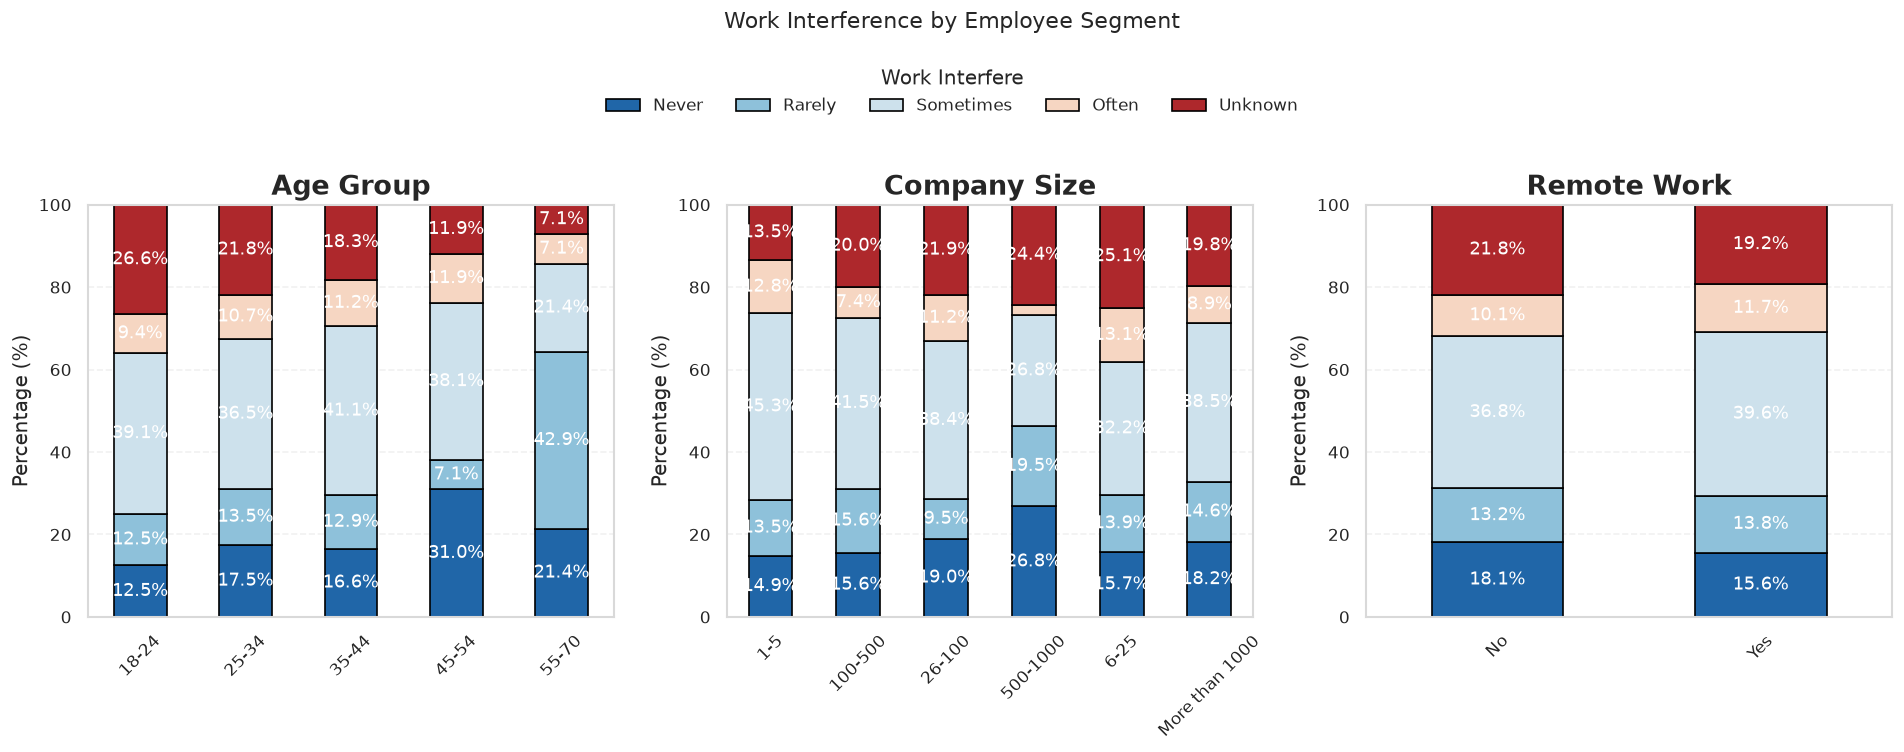

In [51]:
plot_segment_analysis(
    df_tech,
    target="work_interfere",
    title="Work Interference by Employee Segment"
)

In [52]:
df_tech.to_csv("df_tech.csv", index=False)